# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Aprian Syahrani
- **Email:** apyansy@gmail.com
- **ID Dicoding:** aprian_syahrani_z6i4

Dataset ini berasal dari data opensource kaggle:

## Import Semua Packages/Library yang Digunakan

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

## Data Preparation

### Data Loading

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("warcoder/tyre-quality-classification")

print("Path to dataset files:", path)

100%|██████████| 2.66G/2.66G [01:07<00:00, 42.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/warcoder/tyre-quality-classification/versions/1


In [20]:
path_sub = os.path.join(path, "Digital images of defective and good condition tyres")
class_names = [i for i in os.listdir(path_sub) if not i.startswith('.')]
print(f"Classes found: {class_names}")


Classes found: ['defective', 'good']


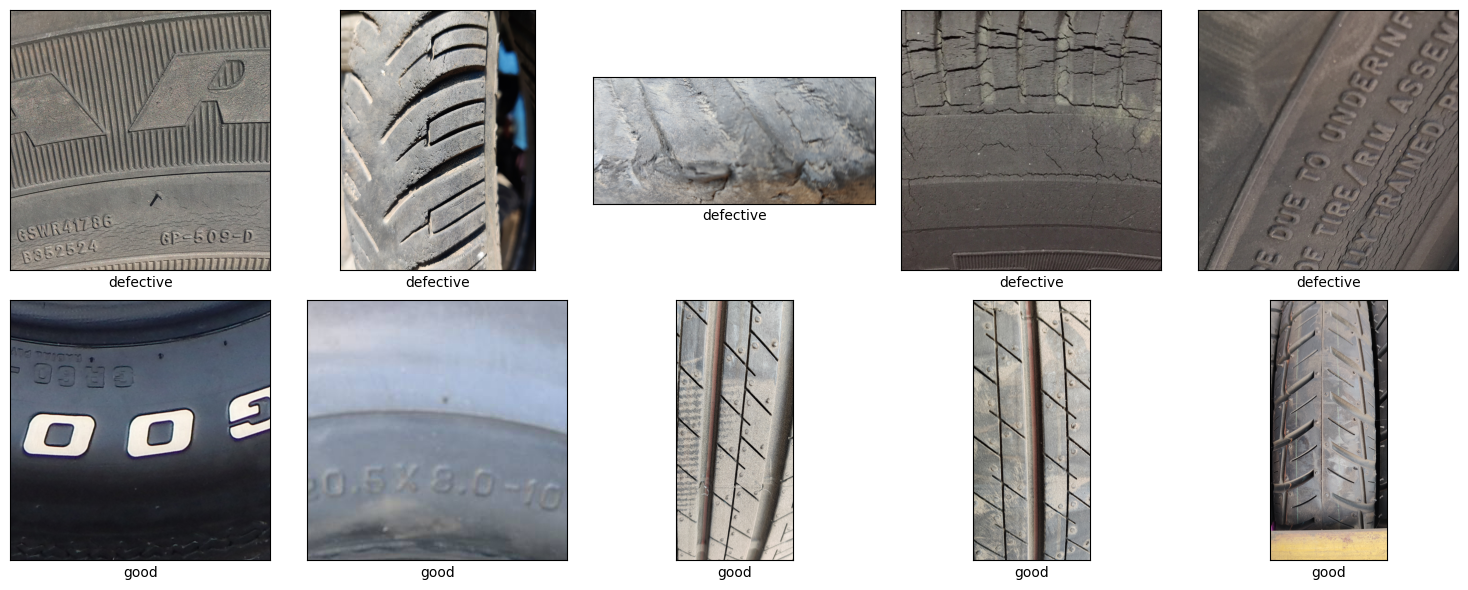

In [17]:
from PIL import Image
fig, axs = plt.subplots(len(class_names), 5, figsize=(15, len(class_names) * 3))
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(path_sub, class_name)
    images = np.random.choice(os.listdir(class_dir), 5, replace=False)
    for j, img_name in enumerate(images):
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path).convert('RGB')
        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])
fig.tight_layout()
plt.show()

{}


/tmp/ipython-input-2359122643.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=list(jumlah_gambar.keys()), x=list(jumlah_gambar.values()), palette='viridis')


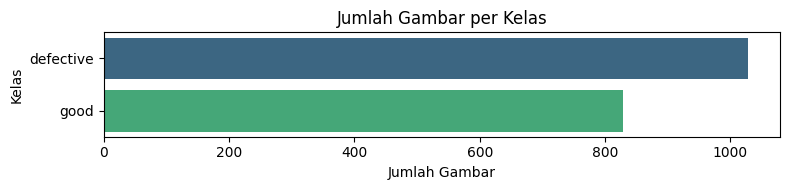

In [ ]:
jumlah_gambar = {}
for class_name in class_names:
    class_dir = os.path.join(path_sub, class_name)
    jumlah_gambar[class_name] = len([f for f in os.listdir(class_dir) if not f.startswith('.')])
plt.figure(figsize=(8, 2))
sns.barplot(y=list(jumlah_gambar.keys()), x=list(jumlah_gambar.values()), palette='viridis')
plt.title('Jumlah Gambar per Kelas')
plt.ylabel('Kelas')
plt.xlabel('Jumlah Gambar')
plt.tight_layout()
plt.show()

In [33]:
print(jumlah_gambar)

{'defective': 1028, 'good': 828}


### Data Preprocessing

#### Split Dataset

In [35]:
import shutil
from sklearn.model_selection import train_test_split

train_dir = path_sub + '_train'
val_dir = path_sub + '_val'
test_dir =  path_sub + '_test'

for dir_path in [train_dir, val_dir, test_dir]:
    for class_name in class_names:
        os.makedirs(os.path.join(dir_path, class_name), exist_ok=True)

# Split data asli menjadi train (70%), val (15%), dan test (15%)
for class_name in class_names:
    class_dir = os.path.join(path_sub, class_name)
    images = os.listdir(class_dir)

    # Split pertama: 70% train, 30% (val + test)
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    # Split kedua: dari 30% (temp), bagi menjadi 15% val dan 15% test
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    # Salin ke direktori train
    for img in train_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(train_dir, class_name, img))
    # Salin ke direktori val
    for img in val_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(val_dir, class_name, img))
    # Salin ke direktori test
    for img in test_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(test_dir, class_name, img))

print("Dataset telah dipisah menjadi train, val, dan test.")

: 

: 

: 

In [ ]:
os.listdir(path_sub)

## Modelling

## Evaluasi dan Visualisasi

## Konversi Model

## Inference (Optional)